For example:

1. scan MIDV folders
2. collect image paths
3. collect annotation paths
4. read annotation JSON
5. build metadata dataframe
6. assign labels
7. save metadata csv
8. optionally generate fake images

Create a metadata table with columns like:

- source_type
- doc_type
- file_stem
- image_path
- annotation_path

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from pathlib import Path

midv_root = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv")

print("Exists:", midv_root.exists())
print("\nTop-level folders:")
for p in midv_root.iterdir():
    print(p.name)

Exists: True

Top-level folders:
photo
scan_rotated
scan_rotated_tif
scan_upright
scan_upright_tif
templates


In [3]:
for p in (midv_root / "photo").rglob("*"):
    print(p)
    break

C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations


In [4]:
from pathlib import Path

photo_folder = midv_root / "photo"

print("First 40 paths under photo:")
for i, p in enumerate(photo_folder.rglob("*")):
    print(p)
    if i >= 39:
        break

First 40 paths under photo:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\aze_passport.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\esp_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\est_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\fin_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\grc_passport.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\lva_passport.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-

In [5]:
from pathlib import Path

midv_root = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv")

matches = list(midv_root.rglob("alb_id"))
print("Found folders named alb_id:")
for m in matches[:20]:
    print(m)

Found folders named alb_id:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\images\alb_id
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\scan_upright_tif\images\alb_id
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\scan_upright\images\alb_id
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\scan_rotated\images\alb_id
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images\alb_id


In [6]:
json_files = list(midv_root.rglob("*.json"))
jpg_files = list(midv_root.rglob("*.jpg"))

print("Number of JSON files:", len(json_files))
print("Number of JPG files:", len(jpg_files))

print("\nFirst 10 JSON files:")
for p in json_files[:10]:
    print(p)

print("\nFirst 10 JPG files:")
for p in jpg_files[:10]:
    print(p)

Number of JSON files: 40
Number of JPG files: 4000

First 10 JSON files:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\alb_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\aze_passport.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\esp_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\est_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\fin_id.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\grc_passport.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\lva_passport.json
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\templates\annotations\rus_internalpassport.json
C:\Users\Admin\Desktop\thesis\m

In [7]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.image_preprocessing import collect_midv_metadata, save_metadata

midv_root = r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv"

midv_metadata = collect_midv_metadata(midv_root)

print(midv_metadata.shape)
midv_metadata.head()

(4000, 6)


,source_type,doc_type,file_name,file_stem,image_path,annotation_path
0,photo,alb_id,00.jpg,00,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
1,photo,alb_id,01.jpg,01,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
2,photo,alb_id,02.jpg,02,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
3,photo,alb_id,03.jpg,03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
4,photo,alb_id,04.jpg,04,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...


In [8]:
midv_metadata["annotation_path"].isna().sum()

np.int64(0)

In [9]:
from pathlib import Path

midv_root = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv")
photo_annotations = midv_root / "photo" / "annotations"
photo_images = midv_root / "photo" / "images"

print("Annotation filenames:")
for p in sorted(photo_annotations.glob("*.json")):
    print(p.stem)

print("\nImage folder names:")
for p in sorted(photo_images.iterdir()):
    if p.is_dir():
        print(p.name)

Annotation filenames:
alb_id
aze_passport
esp_id
est_id
fin_id
grc_passport
lva_passport
rus_internalpassport
srb_passport
svk_id

Image folder names:
alb_id
aze_passport
esp_id
est_id
fin_id
grc_passport
lva_passport
rus_internalpassport
srb_passport
svk_id


In [10]:
ann_names = {p.stem for p in photo_annotations.glob("*.json")}
img_names = {p.name for p in photo_images.iterdir() if p.is_dir()}

print("Only in annotations:")
print(sorted(ann_names - img_names))

print("\nOnly in image folders:")
print(sorted(img_names - ann_names))

Only in annotations:
[]

Only in image folders:
[]


In [11]:
import sys
from pathlib import Path
import importlib

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.image_preprocessing
importlib.reload(src.image_preprocessing)

from src.image_preprocessing import collect_midv_metadata, save_metadata

In [12]:
midv_root = r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv"

midv_metadata = collect_midv_metadata(midv_root)

print(midv_metadata.shape)
print(midv_metadata["annotation_path"].isna().sum())
midv_metadata.head()

(4000, 6)
0


,source_type,doc_type,file_name,file_stem,image_path,annotation_path
0,photo,alb_id,00.jpg,00,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
1,photo,alb_id,01.jpg,01,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
2,photo,alb_id,02.jpg,02,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
3,photo,alb_id,03.jpg,03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...
4,photo,alb_id,04.jpg,04,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...


In [13]:
from pathlib import Path

midv_root = Path(r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv")
annotations_root = midv_root / "photo" / "annotations"

ann_map = {p.stem: str(p) for p in annotations_root.glob("*.json")}

print("alb_id" in ann_map)
print(ann_map.get("alb_id"))

True
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json


In [14]:
import json

sample_json_path = midv_metadata.loc[0, "annotation_path"]

print(sample_json_path)

with open(sample_json_path, "r", encoding="utf-8") as f:
    ann_data = json.load(f)

print(type(ann_data))
print(ann_data)

C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
<class 'dict'>
{'_via_settings': {'ui': {'annotation_editor_height': 25, 'annotation_editor_fontsize': 0.8, 'leftsidebar_width': 18, 'image_grid': {'img_height': 80, 'rshape_fill': 'none', 'rshape_fill_opacity': 0.3, 'rshape_stroke': 'yellow', 'rshape_stroke_width': 2, 'show_region_shape': True, 'show_image_policy': 'all'}, 'image': {'region_label': '__via_region_id__', 'region_color': '__via_default_region_color__', 'region_label_font': '10px Sans', 'on_image_annotation_editor_placement': 'NEAR_REGION'}}, 'core': {'buffer_size': '18', 'filepath': {}, 'default_filepath': '/mnt/midv-2020/photo/images/alb_id/'}, 'project': {'name': 'alb_id'}}, '_via_img_metadata': {'00.jpg4442128': {'filename': '00.jpg', 'size': 4442128, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 771, 'y': 1928, 'width': 204, 'height': 199}, 'region_attributes': {'field_name': 'face', 'value': '', 'features

In [15]:
if isinstance(ann_data, dict):
    print(ann_data.keys())

dict_keys(['_via_settings', '_via_img_metadata', '_via_attributes', '_via_data_format_version', '_via_image_id_list'])


In [16]:
print(type(ann_data["_via_img_metadata"]))
print(type(ann_data["_via_attributes"]))

<class 'dict'>
<class 'dict'>


In [17]:
list(ann_data["_via_img_metadata"].keys())[:5]

['00.jpg4442128',
 '01.jpg4745714',
 '02.jpg4781660',
 '03.jpg5060534',
 '04.jpg5984926']

In [18]:
first_key = list(ann_data["_via_img_metadata"].keys())[0]
print(first_key)
print(ann_data["_via_img_metadata"][first_key])

00.jpg4442128
{'filename': '00.jpg', 'size': 4442128, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 771, 'y': 1928, 'width': 204, 'height': 199}, 'region_attributes': {'field_name': 'face', 'value': '', 'features': {}}}, {'shape_attributes': {'name': 'polygon', 'all_points_x': [613, 2007, 1769, 581], 'all_points_y': [1767, 1674, 2260, 2395]}, 'region_attributes': {'field_name': 'doc_quad'}}], 'file_attributes': {}}


In [19]:
print(ann_data["_via_attributes"])

{'region': {'field_name': {'type': 'text', 'description': '', 'default_value': ''}, 'value': {'type': 'text', 'description': '', 'default_value': ''}, 'features': {'type': 'checkbox', 'description': '', 'options': {'ascenders': '', 'descenders': '', 'lowercase': ''}, 'default_options': {}}}, 'file': {}}


Annotation file contains:

- filename
- size
- regions
- shape_attributes
- region_attributes
- fields like:
- face
- doc_quad

MIDV is annotated for document structure / document analysis, not for fraud vs non-fraud.

In [20]:
save_metadata(
    midv_metadata,
    r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_metadata.csv"
)

All original images get label 0.

In [21]:
midv_metadata["image_label"] = 0
midv_metadata.head()

,source_type,doc_type,file_name,file_stem,image_path,annotation_path,image_label
0,photo,alb_id,00.jpg,00,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,0
1,photo,alb_id,01.jpg,01,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,0
2,photo,alb_id,02.jpg,02,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,0
3,photo,alb_id,03.jpg,03,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,0
4,photo,alb_id,04.jpg,04,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,0


In [22]:
save_metadata(
    midv_metadata,
    r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_metadata_genuine.csv"
)

Since MIDV does not contain a direct fraud label, a binary visual class was constructed by treating original document images as genuine and automatically generated manipulated variants as synthetic fake samples.

In [23]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.image_preprocessing
importlib.reload(src.image_preprocessing)

from src.image_preprocessing import generate_fake_images, save_metadata

In [24]:
test_metadata = midv_metadata.head(3).copy()

test_fake_metadata = generate_fake_images(
    metadata_df=test_metadata,
    output_dir=r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_test_v2"
)

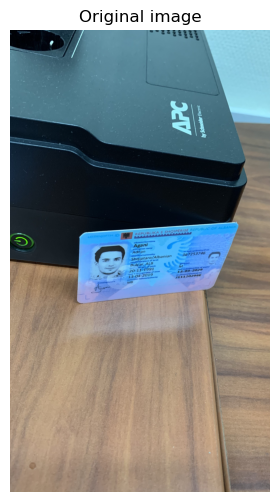

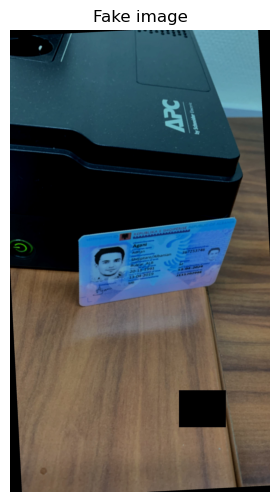

In [25]:
from PIL import Image
import matplotlib.pyplot as plt

orig_path = test_metadata.iloc[0]["image_path"]
fake_path = test_fake_metadata.iloc[0]["image_path"]

orig_img = Image.open(orig_path)
fake_img = Image.open(fake_path)

plt.figure(figsize=(8, 6))
plt.imshow(orig_img)
plt.title("Original image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(fake_img)
plt.title("Fake image")
plt.axis("off")
plt.show()

I tested an automatic pipeline for generating a second visual class from MIDV images. The proof of concept works, but I will refine the manipulation strategy so that the altered images affect the document region itself rather than the image background.

Inspect the doc_quad from one JSON entry.

In [26]:
sample_json_path = midv_metadata.loc[0, "annotation_path"]

import json
with open(sample_json_path, "r", encoding="utf-8") as f:
    ann_data = json.load(f)

first_key = list(ann_data["_via_img_metadata"].keys())[0]
entry = ann_data["_via_img_metadata"][first_key]

print(entry)

{'filename': '00.jpg', 'size': 4442128, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 771, 'y': 1928, 'width': 204, 'height': 199}, 'region_attributes': {'field_name': 'face', 'value': '', 'features': {}}}, {'shape_attributes': {'name': 'polygon', 'all_points_x': [613, 2007, 1769, 581], 'all_points_y': [1767, 1674, 2260, 2395]}, 'region_attributes': {'field_name': 'doc_quad'}}], 'file_attributes': {}}


In [27]:
for region in entry["regions"]:
    print(region)

{'shape_attributes': {'name': 'rect', 'x': 771, 'y': 1928, 'width': 204, 'height': 199}, 'region_attributes': {'field_name': 'face', 'value': '', 'features': {}}}
{'shape_attributes': {'name': 'polygon', 'all_points_x': [613, 2007, 1769, 581], 'all_points_y': [1767, 1674, 2260, 2395]}, 'region_attributes': {'field_name': 'doc_quad'}}


In [28]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.image_preprocessing
importlib.reload(src.image_preprocessing)

from src.image_preprocessing import generate_fake_images_on_document

In [29]:
test_metadata = midv_metadata.head(3).copy()

test_fake_metadata = generate_fake_images_on_document(
    metadata_df=test_metadata,
    output_dir=r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_doc_test"
)

print(test_fake_metadata.shape)
test_fake_metadata.head()


Processing: 00.jpg
Image path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images\alb_id\00.jpg
Annotation path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
Image opened successfully. Size: (2268, 4032)
doc_quad x_points: [613, 2007, 1769, 581]
doc_quad y_points: [1767, 1674, 2260, 2395]
Bounding box: 581 1674 2007 2395
Crop size: (1426, 721)
Saved fake image: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_doc_test\photo\alb_id\00_fake.jpg

Processing: 01.jpg
Image path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images\alb_id\01.jpg
Annotation path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
Image opened successfully. Size: (2268, 4032)
doc_quad x_points: [393, 1710, 1644, 478]
doc_quad y_points: [1305, 1447, 2350, 2076]
Bounding box: 393 1305 1

,source_type,doc_type,file_name,file_stem,image_path,annotation_path,image_label
0,photo,alb_id,00_fake.jpg,00_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
1,photo,alb_id,01_fake.jpg,01_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
2,photo,alb_id,02_fake.jpg,02_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1


In [30]:
print(test_fake_metadata.shape)
test_fake_metadata.head()

(3, 7)


,source_type,doc_type,file_name,file_stem,image_path,annotation_path,image_label
0,photo,alb_id,00_fake.jpg,00_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
1,photo,alb_id,01_fake.jpg,01_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
2,photo,alb_id,02_fake.jpg,02_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1


In [31]:
sample_row = test_metadata.iloc[0]

print("Image file:", sample_row["file_name"])
print("Annotation path:", sample_row["annotation_path"])

Image file: 00.jpg
Annotation path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json


In [32]:
import json

with open(sample_row["annotation_path"], "r", encoding="utf-8") as f:
    ann_data = json.load(f)

print(sample_row["file_name"])

for key, item in ann_data["_via_img_metadata"].items():
    if item.get("filename") == sample_row["file_name"]:
        print("MATCH FOUND")
        print(item)
        break
else:
    print("NO MATCH FOUND")

00.jpg
MATCH FOUND
{'filename': '00.jpg', 'size': 4442128, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 771, 'y': 1928, 'width': 204, 'height': 199}, 'region_attributes': {'field_name': 'face', 'value': '', 'features': {}}}, {'shape_attributes': {'name': 'polygon', 'all_points_x': [613, 2007, 1769, 581], 'all_points_y': [1767, 1674, 2260, 2395]}, 'region_attributes': {'field_name': 'doc_quad'}}], 'file_attributes': {}}


In [33]:
import sys
import importlib
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.image_preprocessing
importlib.reload(src.image_preprocessing)

from src.image_preprocessing import generate_fake_images_on_document

In [34]:
test_metadata = midv_metadata.head(1).copy()

test_fake_metadata = generate_fake_images_on_document(
    metadata_df=test_metadata,
    output_dir=r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_doc_test"
)

print("\nResult shape:", test_fake_metadata.shape)
print(test_fake_metadata)


Processing: 00.jpg
Image path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images\alb_id\00.jpg
Annotation path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
Image opened successfully. Size: (2268, 4032)
doc_quad x_points: [613, 2007, 1769, 581]
doc_quad y_points: [1767, 1674, 2260, 2395]
Bounding box: 581 1674 2007 2395
Crop size: (1426, 721)
Saved fake image: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_doc_test\photo\alb_id\00_fake.jpg

Result shape: (1, 7)
  source_type doc_type    file_name file_stem  \
0       photo   alb_id  00_fake.jpg   00_fake   

                                          image_path  \
0  C:\Users\Admin\Desktop\thesis\multimodal-fraud...   

                                     annotation_path  image_label  
0  C:\Users\Admin\Desktop\thesis\multimodal-fraud...            1  


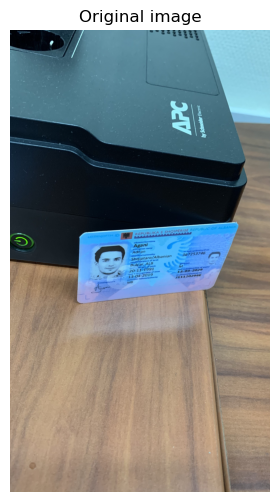

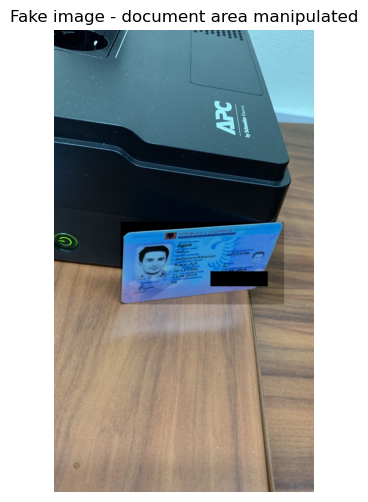

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

orig_path = test_metadata.iloc[0]["image_path"]
fake_path = test_fake_metadata.iloc[0]["image_path"]

orig_img = Image.open(orig_path)
fake_img = Image.open(fake_path)

plt.figure(figsize=(8, 6))
plt.imshow(orig_img)
plt.title("Original image")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(fake_img)
plt.title("Fake image - document area manipulated")
plt.axis("off")
plt.show()

In [38]:
test_metadata_10 = midv_metadata.head(10).copy()

test_fake_metadata_10 = generate_fake_images_on_document(
    metadata_df=test_metadata_10,
    output_dir=r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_doc_test10"
)

print(test_fake_metadata_10.shape)
test_fake_metadata_10.head()


Processing: 00.jpg
Image path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images\alb_id\00.jpg
Annotation path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
Image opened successfully. Size: (2268, 4032)
doc_quad x_points: [613, 2007, 1769, 581]
doc_quad y_points: [1767, 1674, 2260, 2395]
Bounding box: 581 1674 2007 2395
Crop size: (1426, 721)
Saved fake image: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_fake_images_doc_test10\photo\alb_id\00_fake.jpg

Processing: 01.jpg
Image path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\images\alb_id\01.jpg
Annotation path: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\midv\photo\annotations\alb_id.json
Image opened successfully. Size: (2268, 4032)
doc_quad x_points: [393, 1710, 1644, 478]
doc_quad y_points: [1305, 1447, 2350, 2076]
Bounding box: 393 1305

,source_type,doc_type,file_name,file_stem,image_path,annotation_path,image_label
0,photo,alb_id,00_fake.jpg,00_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
1,photo,alb_id,01_fake.jpg,01_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
2,photo,alb_id,02_fake.jpg,02_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
3,photo,alb_id,03_fake.jpg,03_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1
4,photo,alb_id,04_fake.jpg,04_fake,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,C:\Users\Admin\Desktop\thesis\multimodal-fraud...,1


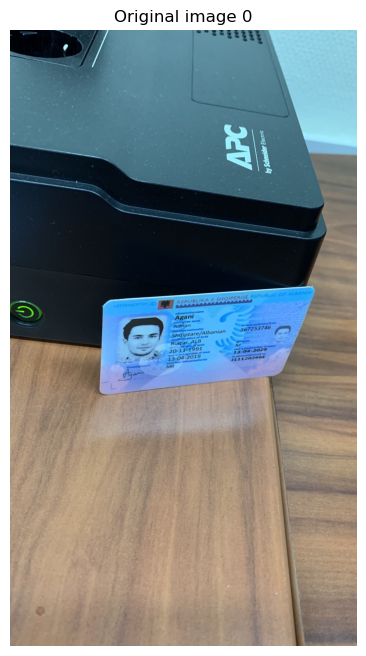

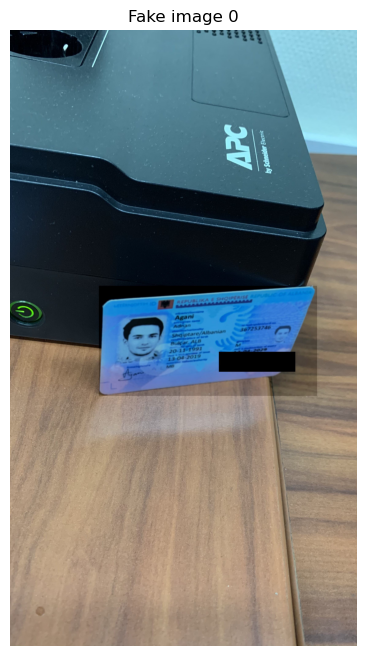

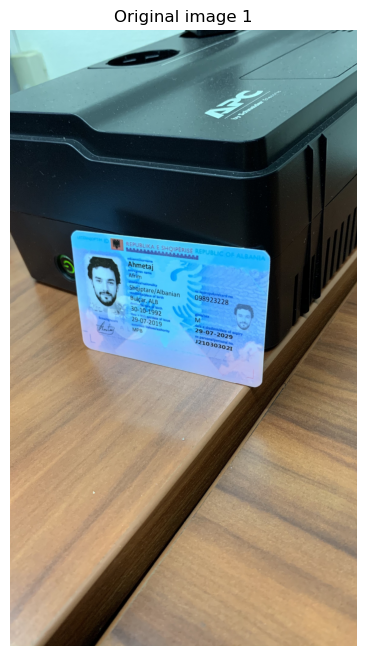

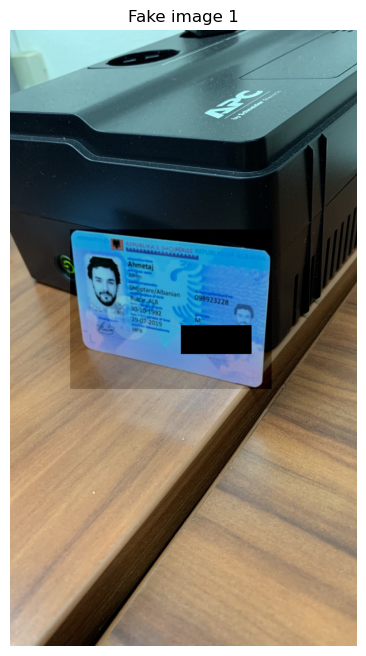

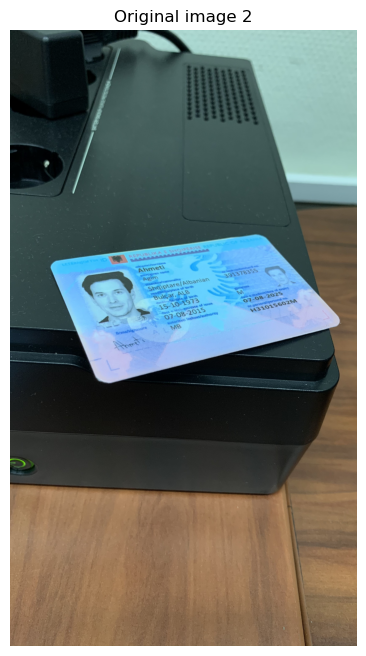

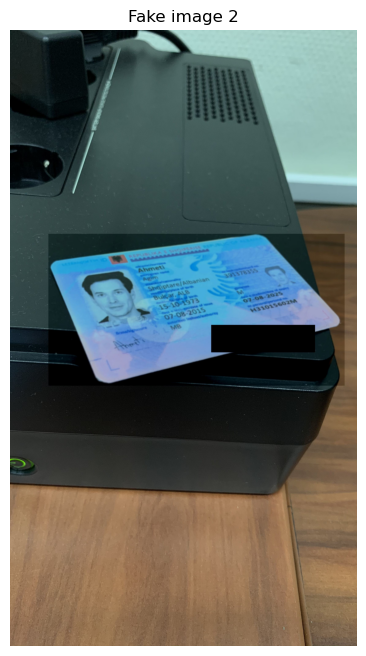

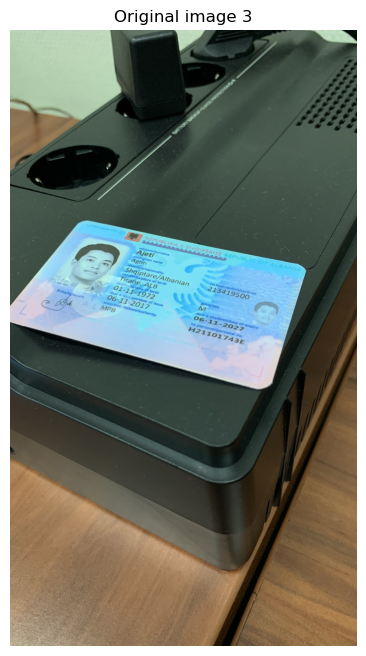

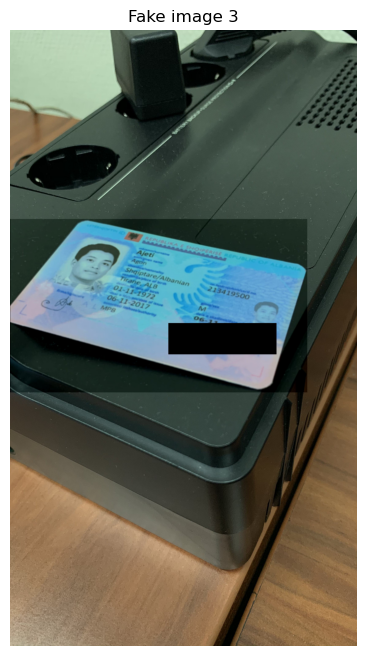

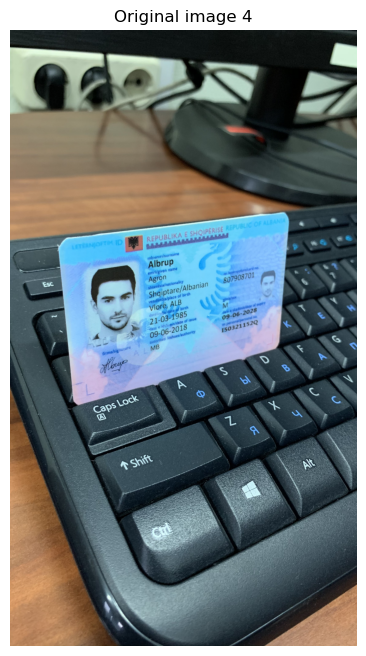

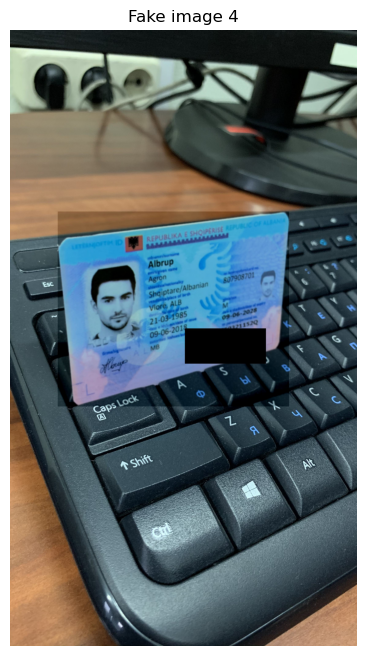

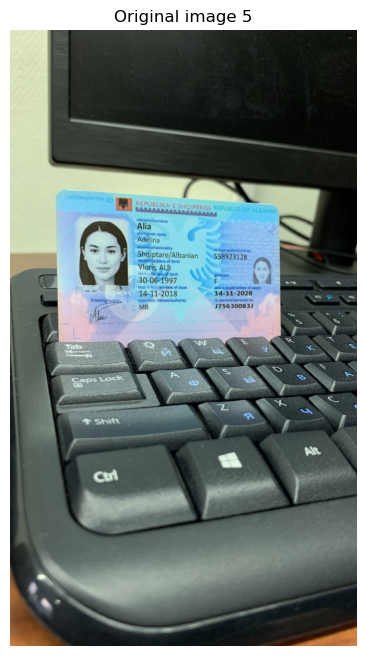

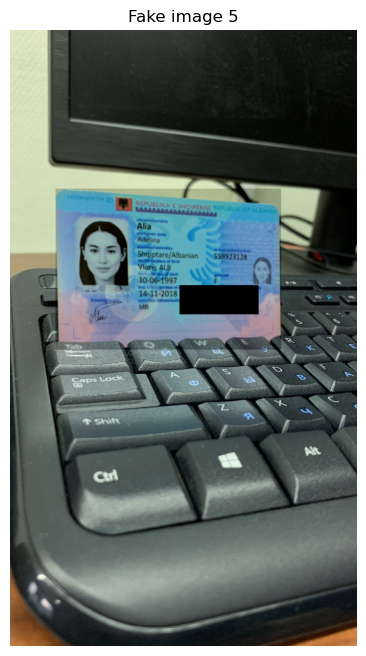

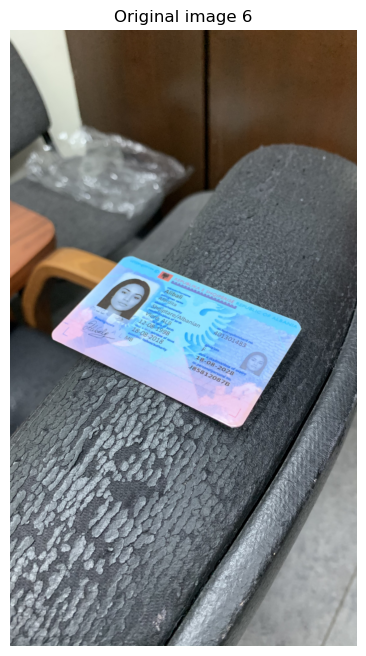

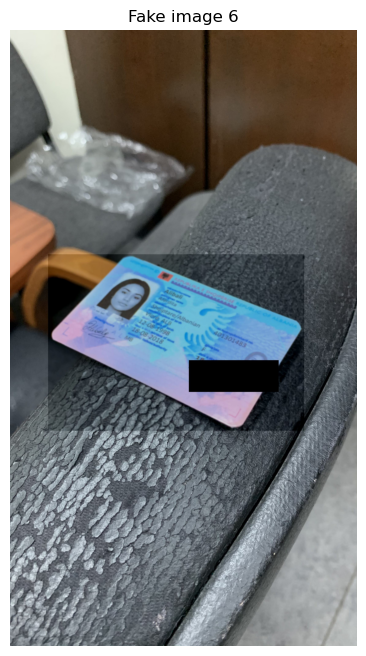

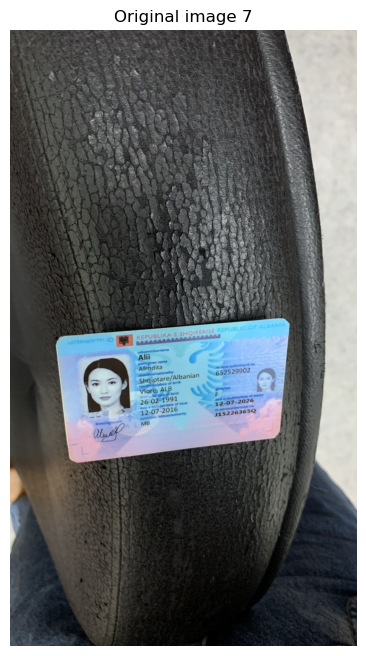

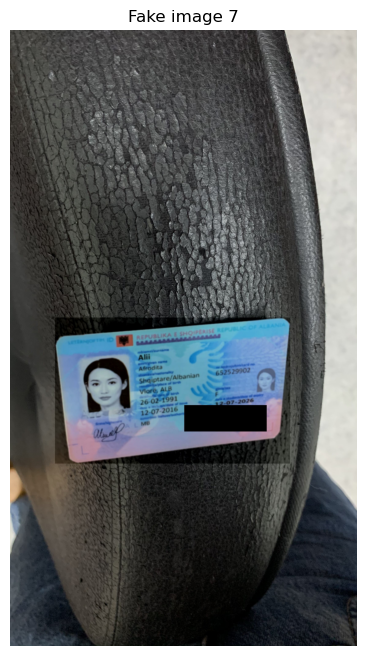

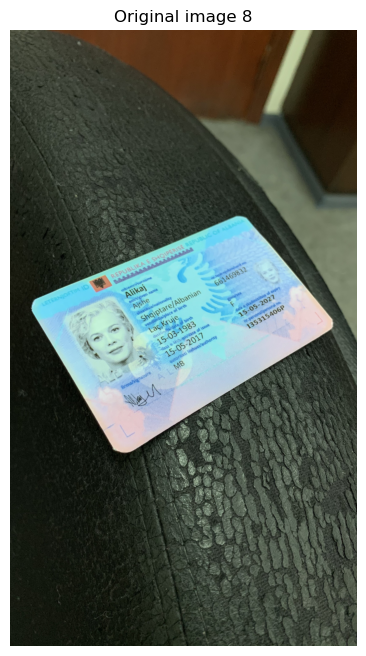

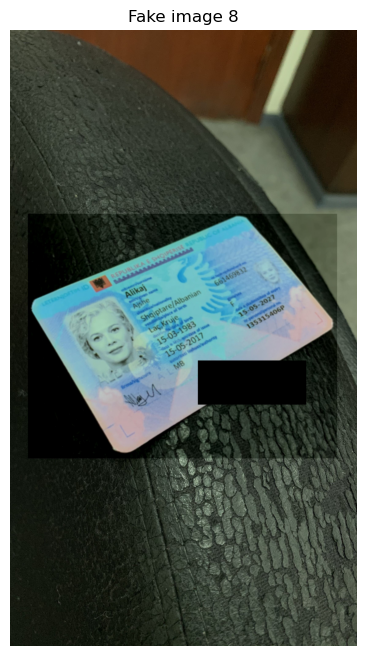

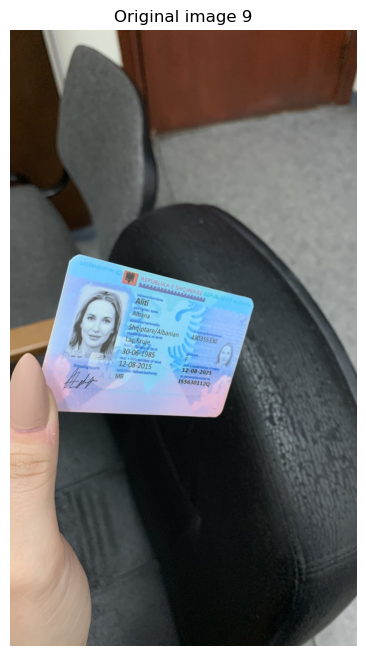

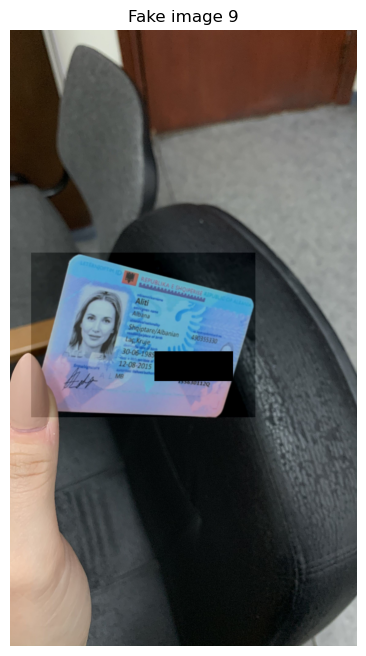

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

for i in range(min(10, len(test_fake_metadata_10))):
    orig_path = test_metadata_10.iloc[i]["image_path"]
    fake_path = test_fake_metadata_10.iloc[i]["image_path"]

    orig_img = Image.open(orig_path)
    fake_img = Image.open(fake_path)

    plt.figure(figsize=(6, 8))
    plt.imshow(orig_img)
    plt.title(f"Original image {i}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 8))
    plt.imshow(fake_img)
    plt.title(f"Fake image {i}")
    plt.axis("off")
    plt.show()